In [2]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar, minimize
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed -- running without it (pip install lightgbm to enable)")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

print("Libraries imported")
print(f"LightGBM available: {HAS_LGB}")


# ---------------------------------------------------------------------------
# FILE PATHS AND CONSTANTS
# ---------------------------------------------------------------------------
KAGGLE_PATH = "/kaggle/input/march-machine-learning-mania-2026"
LOCAL_PATH  = r"C:\Users\aayus\Documents\march-ml-mania-2026\data"
DATA        = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

OUTPUT_PATH = r"C:\Users\aayus\Documents\march-ml-mania-2026\notebooks\march_madness_2026_submission_final.csv"

SOFT_CLIP_LOW  = 0.02
SOFT_CLIP_HIGH = 0.98

# Season recency decay: rows from older seasons get lower weight in training.
# w = RECENCY_DECAY ^ (max_season - season). 0.9 means 2 seasons ago = 81% weight.
RECENCY_DECAY  = 0.90

XGB_PARAMS = dict(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_lambda=2.0,
    eval_metric="logloss", random_state=42, verbosity=0,
)

LGB_PARAMS = dict(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_lambda=2.0,
    random_state=42, verbose=-1,
)

MASSEY_INDIVIDUAL = ["NET", "BPI", "SAG", "MOR", "TRP", "POM", "KPI", "DOL", "RPI", "COL"]

# Historical upset rate by seed difference bucket.
# Source: historical tournament data 1985-2025.
# Used to add a matchup-structure feature that the model can anchor on.
SEED_UPSET_RATES = {
    (1, 16): 0.013, (2, 15): 0.060, (3, 14): 0.133, (4, 13): 0.208,
    (5, 12): 0.356, (6, 11): 0.370, (7, 10): 0.393, (8,  9): 0.481,
}

def p(f):
    return os.path.join(DATA, f)

print(f"Data folder: {os.path.abspath(DATA)}")


# ---------------------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------------------
print("\nLoading data...")

m_season  = pd.read_csv(p("MRegularSeasonCompactResults.csv"))
m_tourney = pd.read_csv(p("MNCAATourneyCompactResults.csv"))
m_seeds   = pd.read_csv(p("MNCAATourneySeeds.csv"))
m_massey  = pd.read_csv(p("MMasseyOrdinals.csv"))
m_teams   = pd.read_csv(p("MTeams.csv"))

w_season  = pd.read_csv(p("WRegularSeasonCompactResults.csv"))
w_tourney = pd.read_csv(p("WNCAATourneyCompactResults.csv"))
w_seeds   = pd.read_csv(p("WNCAATourneySeeds.csv"))

sample_sub = pd.read_csv(p("SampleSubmissionStage2.csv"))

# Conference data (may or may not exist in the dataset)
conf_path = p("MTeamConferences.csv")
m_conf = pd.read_csv(conf_path) if os.path.exists(conf_path) else pd.DataFrame()

print(f"  MRegularSeasonCompactResults : {len(m_season):>8,} rows")
print(f"  MNCAATourneyCompactResults   : {len(m_tourney):>8,} rows")
print(f"  MNCAATourneySeeds            : {len(m_seeds):>8,} rows")
print(f"  MMasseyOrdinals              : {len(m_massey):>8,} rows")
print(f"  WRegularSeasonCompactResults : {len(w_season):>8,} rows")
print(f"  WNCAATourneyCompactResults   : {len(w_tourney):>8,} rows")
print(f"  WNCAATourneySeeds            : {len(w_seeds):>8,} rows")
print(f"  MTeamConferences             : {'not found' if len(m_conf)==0 else len(m_conf):>8} rows")
print(f"  SampleSubmissionStage2       : {len(sample_sub):>8,} rows")
print(f"  Sample IDs: {sample_sub['ID'].head(3).tolist()}")
print("All files loaded")


# ---------------------------------------------------------------------------
# POST-BLEND TRANSFORMATIONS (no hard clip)
# ---------------------------------------------------------------------------
def apply_temperature(preds, T):
    preds = np.clip(preds, 1e-9, 1.0 - 1e-9)
    logit = np.log(preds / (1.0 - preds))
    return 1.0 / (1.0 + np.exp(-logit / T))

def apply_shrink(preds, alpha):
    return 0.5 + (preds - 0.5) * alpha

def apply_postprocess(preds, T, alpha):
    return np.clip(apply_shrink(apply_temperature(preds, T), alpha),
                   SOFT_CLIP_LOW, SOFT_CLIP_HIGH)

def find_optimal_T_and_alpha(y_true, blend_preds):
    best_brier = 999.0
    best_T = 1.0
    best_alpha = 1.0
    for T_cand in np.arange(0.8, 4.1, 0.2):
        temp_scaled = apply_temperature(blend_preds, T_cand)
        res = minimize_scalar(
            lambda a: brier_score_loss(
                y_true,
                np.clip(apply_shrink(temp_scaled, a), SOFT_CLIP_LOW, SOFT_CLIP_HIGH)
            ),
            bounds=(0.5, 1.0), method="bounded",
        )
        b = brier_score_loss(
            y_true,
            np.clip(apply_shrink(temp_scaled, res.x), SOFT_CLIP_LOW, SOFT_CLIP_HIGH)
        )
        if b < best_brier:
            best_brier = b
            best_T     = T_cand
            best_alpha = float(res.x)
    return best_T, best_alpha


# ---------------------------------------------------------------------------
# SAFE IMPUTE
# ---------------------------------------------------------------------------
def safe_impute(df, features, ref_median=None):
    valid = [f for f in features if f in df.columns]
    X     = df[valid].copy()
    med   = X.median() if ref_median is None else ref_median[valid]
    X     = X.fillna(med).fillna(0)
    return X, valid, med if ref_median is None else ref_median


# ---------------------------------------------------------------------------
# RECENCY WEIGHTS
# More recent tournament seasons get higher weight in model training.
# ---------------------------------------------------------------------------
def make_sample_weights(seasons_series, decay=RECENCY_DECAY):
    max_s = seasons_series.max()
    return decay ** (max_s - seasons_series)


# ---------------------------------------------------------------------------
# ELO WITH MARGIN-OF-VICTORY (MOV-ELO)
# Standard Elo ignores score margin. MOV-Elo scales K by log(score_diff+1)
# divided by an autocorrelation correction that prevents runaway ratings.
# This is the same approach used by FiveThirtyEight for NFL/NBA predictions.
# ---------------------------------------------------------------------------
def compute_elo(season_df, K=24, initial=1500, carry=0.75, use_mov=True):
    all_seasons = sorted(season_df["Season"].unique())
    ratings = {}
    records = []

    for season in all_seasons:
        grp = season_df[season_df["Season"] == season].sort_values("DayNum")
        current = {tid: initial + carry * (r - initial) for tid, r in ratings.items()}

        def get_elo(tid):
            return current.get(int(tid), initial)

        for _, row in grp.iterrows():
            w_id   = int(row["WTeamID"])
            l_id   = int(row["LTeamID"])
            ew     = get_elo(w_id)
            el     = get_elo(l_id)
            exp_w  = 1.0 / (1.0 + 10.0 ** ((el - ew) / 400.0))

            if use_mov and "WScore" in row and "LScore" in row:
                score_diff = abs(row["WScore"] - row["LScore"])
                # Autocorrelation correction: prevents margin from inflating
                # ratings of teams that win by blowout consistently
                autocorr   = 2.2 / ((ew - el) * 0.001 + 2.2)
                k_eff      = K * np.log1p(score_diff) * autocorr
            else:
                k_eff = K

            current[w_id] = ew + k_eff * (1.0 - exp_w)
            current[l_id] = el + k_eff * (0.0 - (1.0 - exp_w))

        for tid, elo_val in current.items():
            records.append({"Season": season, "TeamID": tid, "Elo": elo_val})
        ratings = current

    df = pd.DataFrame(records)
    print(f"    MOV-Elo: {df['Season'].nunique()} seasons, {df['TeamID'].nunique()} teams")
    return df


# ---------------------------------------------------------------------------
# RECENT FORM
# ---------------------------------------------------------------------------
def compute_recent_form(season_df, last_n=10):
    w = season_df[["Season","DayNum","WTeamID"]].rename(
        columns={"WTeamID":"TeamID"}).assign(Won=1)
    l = season_df[["Season","DayNum","LTeamID"]].rename(
        columns={"LTeamID":"TeamID"}).assign(Won=0)
    all_g = pd.concat([w, l]).sort_values(["Season","TeamID","DayNum"])
    return (all_g.groupby(["Season","TeamID"])["Won"]
            .apply(lambda x: x.tail(last_n).mean())
            .reset_index(name="RecentForm"))


# ---------------------------------------------------------------------------
# PACE-ADJUSTED EFFICIENCY
# ---------------------------------------------------------------------------
def compute_efficiency(season_df):
    season_df = season_df.copy()
    season_df["TotalScore"] = season_df["WScore"] + season_df["LScore"]
    avg_total = season_df.groupby("Season")["TotalScore"].mean().reset_index(name="SeasonAvgTotal")

    pts_w = season_df[["Season","WTeamID","WScore"]].rename(columns={"WTeamID":"TeamID","WScore":"Pts"})
    pts_l = season_df[["Season","LTeamID","LScore"]].rename(columns={"LTeamID":"TeamID","LScore":"Pts"})
    alw_w = season_df[["Season","WTeamID","LScore"]].rename(columns={"WTeamID":"TeamID","LScore":"Alw"})
    alw_l = season_df[["Season","LTeamID","WScore"]].rename(columns={"LTeamID":"TeamID","WScore":"Alw"})

    avg_pts = pd.concat([pts_w,pts_l]).groupby(["Season","TeamID"])["Pts"].mean().reset_index(name="RawOffense")
    avg_alw = pd.concat([alw_w,alw_l]).groupby(["Season","TeamID"])["Alw"].mean().reset_index(name="RawDefense")

    eff = avg_pts.merge(avg_alw, on=["Season","TeamID"]).merge(avg_total, on="Season")
    eff["AdjOE"]  = (eff["RawOffense"] / eff["SeasonAvgTotal"]) * 100
    eff["AdjDE"]  = (eff["RawDefense"] / eff["SeasonAvgTotal"]) * 100
    eff["NetEff"] = eff["AdjOE"] - eff["AdjDE"]
    return eff[["Season","TeamID","AdjOE","AdjDE","NetEff"]]


# ---------------------------------------------------------------------------
# STRENGTH OF SCHEDULE
# ---------------------------------------------------------------------------
def compute_sos(season_df, elo_df):
    wg = season_df[["Season","WTeamID","LTeamID"]].rename(columns={"WTeamID":"TeamID","LTeamID":"OppID"})
    lg = season_df[["Season","LTeamID","WTeamID"]].rename(columns={"LTeamID":"TeamID","WTeamID":"OppID"})
    all_g = pd.concat([wg, lg])
    opp   = elo_df.rename(columns={"TeamID":"OppID","Elo":"OppElo"})
    all_g = all_g.merge(opp, on=["Season","OppID"], how="left")
    return all_g.groupby(["Season","TeamID"])["OppElo"].mean().reset_index(name="SOS")


# ---------------------------------------------------------------------------
# CONFERENCE QUALITY
# Average Elo of all teams in a team's conference, per season.
# Better proxy for schedule difficulty than SOS alone, because it
# captures the baseline quality of the pool a team competes in.
# ---------------------------------------------------------------------------
def compute_conference_quality(season_df, elo_df, conf_df):
    if len(conf_df) == 0:
        return pd.DataFrame(columns=["Season","TeamID","ConfQuality"])

    conf_elo = elo_df.merge(conf_df[["Season","TeamID","ConfAbbrev"]],
                            on=["Season","TeamID"], how="left")
    conf_avg = (conf_elo.groupby(["Season","ConfAbbrev"])["Elo"]
                .mean().reset_index(name="ConfAvgElo"))
    result   = conf_elo.merge(conf_avg, on=["Season","ConfAbbrev"], how="left")
    return result[["Season","TeamID","ConfAvgElo"]].rename(columns={"ConfAvgElo":"ConfQuality"})


# ---------------------------------------------------------------------------
# MASSEY CONSENSUS RANK
# ---------------------------------------------------------------------------
def compute_massey_features(massey_df, individual_systems):
    pre    = massey_df[massey_df["RankingDayNum"] <= 133].copy()
    latest = pre.sort_values("RankingDayNum").groupby(["Season","TeamID","SystemName"]).tail(1)
    pivot  = latest.pivot_table(index=["Season","TeamID"], columns="SystemName",
                                values="OrdinalRank").reset_index()
    pivot.columns.name = None

    sys_cols = [c for c in pivot.columns if c not in ["Season","TeamID"]]
    pivot["MasseyConsensus"] = pivot[sys_cols].median(axis=1)

    available = [s for s in individual_systems if s in pivot.columns]
    missing   = [s for s in individual_systems if s not in pivot.columns]
    if missing:
        print(f"    Massey not in data: {missing}")

    keep   = ["Season","TeamID","MasseyConsensus"] + available
    result = pivot[[c for c in keep if c in pivot.columns]].copy()
    print(f"    Massey: {len(sys_cols)} systems -> consensus + {len(available)} individual")
    return result


# ---------------------------------------------------------------------------
# HISTORICAL UPSET RATE BY SEED MATCHUP
# Looks up the actual historical upset probability for a given seed pairing.
# This directly encodes tournament structure knowledge the model would
# otherwise have to learn from limited data.
# ---------------------------------------------------------------------------
def seed_pair_upset_rate(seed_a, seed_b):
    if pd.isna(seed_a) or pd.isna(seed_b):
        return 0.35
    sa, sb = int(seed_a), int(seed_b)
    lo, hi = min(sa, sb), max(sa, sb)
    return SEED_UPSET_RATES.get((lo, hi), 0.35)


# ---------------------------------------------------------------------------
# TEAM STATISTICS
# ---------------------------------------------------------------------------
def build_team_stats(season_df, seeds_df, massey_df, conf_df, label=""):
    print(f"\n  [{label}] Building team stats...")

    wins   = season_df.groupby(["Season","WTeamID"]).size().reset_index(name="Wins").rename(columns={"WTeamID":"TeamID"})
    losses = season_df.groupby(["Season","LTeamID"]).size().reset_index(name="Losses").rename(columns={"LTeamID":"TeamID"})
    stats  = pd.merge(wins, losses, on=["Season","TeamID"], how="outer").fillna(0)
    stats["Games"]   = stats["Wins"] + stats["Losses"]
    stats["WinRate"] = stats["Wins"] / stats["Games"]

    pts_w = season_df[["Season","WTeamID","WScore"]].rename(columns={"WTeamID":"TeamID","WScore":"Pts"})
    pts_l = season_df[["Season","LTeamID","LScore"]].rename(columns={"LTeamID":"TeamID","LScore":"Pts"})
    alw_w = season_df[["Season","WTeamID","LScore"]].rename(columns={"WTeamID":"TeamID","LScore":"Alw"})
    alw_l = season_df[["Season","LTeamID","WScore"]].rename(columns={"LTeamID":"TeamID","WScore":"Alw"})

    avg_pts = pd.concat([pts_w,pts_l]).groupby(["Season","TeamID"])["Pts"].mean().reset_index(name="AvgPoints")
    avg_alw = pd.concat([alw_w,alw_l]).groupby(["Season","TeamID"])["Alw"].mean().reset_index(name="AvgPointsAllowed")

    stats = stats.merge(avg_pts, on=["Season","TeamID"], how="left")
    stats = stats.merge(avg_alw, on=["Season","TeamID"], how="left")
    stats["PointDiff"] = stats["AvgPoints"] - stats["AvgPointsAllowed"]

    elo  = compute_elo(season_df, use_mov=True)
    stats = stats.merge(elo, on=["Season","TeamID"], how="left")

    sos  = compute_sos(season_df, elo)
    stats = stats.merge(sos, on=["Season","TeamID"], how="left")

    cq   = compute_conference_quality(season_df, elo, conf_df)
    if len(cq) > 0:
        stats = stats.merge(cq, on=["Season","TeamID"], how="left")
    else:
        stats["ConfQuality"] = np.nan

    form = compute_recent_form(season_df)
    stats = stats.merge(form, on=["Season","TeamID"], how="left")

    eff  = compute_efficiency(season_df)
    stats = stats.merge(eff, on=["Season","TeamID"], how="left")

    s = seeds_df.copy()
    s["SeedNum"] = s["Seed"].str[1:3].astype(int)
    stats = stats.merge(s[["Season","TeamID","SeedNum"]], on=["Season","TeamID"], how="left")

    if len(massey_df) > 0:
        mf    = compute_massey_features(massey_df, MASSEY_INDIVIDUAL)
        stats = stats.merge(mf, on=["Season","TeamID"], how="left")
    else:
        for col in ["MasseyConsensus"] + MASSEY_INDIVIDUAL:
            stats[col] = np.nan
        print("    No Massey data -- all Massey columns set to NaN")

    print(f"  [{label}] {len(stats):,} rows | "
          f"{stats['Season'].nunique()} seasons | "
          f"{stats['TeamID'].nunique()} teams")
    return stats


# ---------------------------------------------------------------------------
# FEATURE LIST
# New features vs v4:
#   OffVsDefA/B -- interaction: team A offense vs team B defense (tempo clash)
#   UpsetRate   -- historical upset probability for this seed matchup
#   ConfQualityDiff -- conference strength difference
# ---------------------------------------------------------------------------
MASSEY_DIFF_COLS = ["MasseyConsensusDiff"] + [f"{s}Diff" for s in MASSEY_INDIVIDUAL]

ALL_FEATURES = [
    "WinRateDiff",
    "PointDiffDiff",
    "EloDiff",
    "RecentFormDiff",
    "SeedDiff",
    "SOSDiff",
    "ConfQualityDiff",    # new: conference strength difference
    "AdjOEDiff",
    "AdjDEDiff",
    "NetEffDiff",
    "OffVsDefA",          # new: team A offense quality vs team B defense quality
    "OffVsDefB",          # new: team B offense quality vs team A defense quality
    "UpsetRate",          # new: historical upset probability for this seed pair
] + MASSEY_DIFF_COLS


# ---------------------------------------------------------------------------
# MATCHUP DATASET
# ---------------------------------------------------------------------------
def build_matchup_dataset(tourney_df, stats_df, label=""):
    print(f"\n  [{label}] Building matchup dataset...")

    def attach(df, team_col, sfx):
        tmp = stats_df.copy()
        tmp.columns = [c if c in ["Season","TeamID"] else c+sfx for c in tmp.columns]
        return df.merge(tmp.rename(columns={"TeamID": team_col}),
                        on=["Season", team_col], how="left")

    df = attach(attach(tourney_df.copy(), "WTeamID", "_W"), "LTeamID", "_L")

    def make_rows(df, a, b, target):
        r = pd.DataFrame()
        r["Season"]         = df["Season"]
        r["Target"]         = target
        r["WinRateDiff"]    = df[f"WinRate{a}"]    - df[f"WinRate{b}"]
        r["PointDiffDiff"]  = df[f"PointDiff{a}"]  - df[f"PointDiff{b}"]
        r["EloDiff"]        = df[f"Elo{a}"]         - df[f"Elo{b}"]
        r["RecentFormDiff"] = df[f"RecentForm{a}"]  - df[f"RecentForm{b}"]
        r["SeedDiff"]       = df[f"SeedNum{a}"]     - df[f"SeedNum{b}"]
        r["SOSDiff"]        = df[f"SOS{a}"]         - df[f"SOS{b}"]
        r["AdjOEDiff"]      = df[f"AdjOE{a}"]       - df[f"AdjOE{b}"]
        r["AdjDEDiff"]      = df[f"AdjDE{a}"]       - df[f"AdjDE{b}"]
        r["NetEffDiff"]     = df[f"NetEff{a}"]      - df[f"NetEff{b}"]

        # Conference quality (may be NaN if file not available)
        cqa = f"ConfQuality{a}" if f"ConfQuality{a}" in df.columns else None
        cqb = f"ConfQuality{b}" if f"ConfQuality{b}" in df.columns else None
        r["ConfQualityDiff"] = (df[cqa] - df[cqb]) if (cqa and cqb) else np.nan

        # Interaction features: how does team A's offense match up vs team B's defense?
        # AdjOE_A is high = team A scores well. AdjDE_B is low = team B allows few points.
        # AdjOE_A - AdjDE_B captures the expected scoring advantage of A over B's defense.
        r["OffVsDefA"] = df[f"AdjOE{a}"] - df[f"AdjDE{b}"]
        r["OffVsDefB"] = df[f"AdjOE{b}"] - df[f"AdjDE{a}"]

        # Historical upset rate for this seed matchup
        sa = f"SeedNum{a}"
        sb = f"SeedNum{b}"
        if sa in df.columns and sb in df.columns:
            r["UpsetRate"] = [
                seed_pair_upset_rate(row[sa], row[sb])
                for _, row in df.iterrows()
            ]
        else:
            r["UpsetRate"] = 0.35

        ca, cb = f"MasseyConsensus{a}", f"MasseyConsensus{b}"
        r["MasseyConsensusDiff"] = (df[ca] - df[cb]
                                    if ca in df.columns and cb in df.columns
                                    else np.nan)
        for sys in MASSEY_INDIVIDUAL:
            ca, cb = f"{sys}{a}", f"{sys}{b}"
            r[f"{sys}Diff"] = (df[ca] - df[cb]
                               if ca in df.columns and cb in df.columns
                               else np.nan)
        return r

    combined = pd.concat(
        [make_rows(df, "_W", "_L", 1), make_rows(df, "_L", "_W", 0)],
        ignore_index=True
    )
    print(f"  [{label}] {len(combined):,} rows ({len(df):,} games x 2) | "
          f"{combined['Season'].nunique()} seasons")
    return combined


# ---------------------------------------------------------------------------
# MODEL BUILDERS
# Four-model ensemble: LR, Ridge, XGB, LightGBM (if available)
# Using sigmoid calibration throughout (2 params, stable on small datasets)
# ---------------------------------------------------------------------------
def build_lr(X_tr, y_tr, sample_weight=None):
    sc = StandardScaler()
    lr = LogisticRegression(max_iter=2000, C=0.5, random_state=42)
    lr.fit(sc.fit_transform(X_tr), y_tr, sample_weight=sample_weight)
    return lr, sc

def build_ridge(X_tr, y_tr, sample_weight=None):
    sc  = StandardScaler()
    rdg = CalibratedClassifierCV(
        RidgeClassifier(alpha=1.0), method="sigmoid", cv=3
    )
    rdg.fit(sc.fit_transform(X_tr), y_tr, sample_weight=sample_weight)
    return rdg, sc

def build_xgb(X_tr, y_tr, sample_weight=None):
    xgb_raw = XGBClassifier(**XGB_PARAMS)
    xgb_cal = CalibratedClassifierCV(xgb_raw, method="sigmoid", cv=3)
    xgb_cal.fit(X_tr, y_tr, sample_weight=sample_weight)
    return xgb_cal

def build_lgb(X_tr, y_tr, sample_weight=None):
    if not HAS_LGB:
        return None
    lgb_raw = lgb.LGBMClassifier(**LGB_PARAMS)
    lgb_cal = CalibratedClassifierCV(lgb_raw, method="sigmoid", cv=3)
    lgb_cal.fit(X_tr, y_tr, sample_weight=sample_weight)
    return lgb_cal


# ---------------------------------------------------------------------------
# BLEND WEIGHT OPTIMISER FOR N MODELS
# Finds weights w_1..w_n that minimise Brier on validation set.
# Constrained: all weights >= 0, sum to 1.
# ---------------------------------------------------------------------------
def optimise_blend_weights(y_true, model_preds_list):
    n = len(model_preds_list)
    stacked = np.stack(model_preds_list, axis=1)

    def neg_brier(weights):
        blend = stacked @ weights
        return brier_score_loss(y_true, blend)

    from scipy.optimize import minimize as sp_minimize
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds      = [(0.0, 1.0)] * n
    x0          = np.ones(n) / n

    res = sp_minimize(neg_brier, x0, method="SLSQP",
                      bounds=bounds, constraints=constraints)
    return res.x


# ---------------------------------------------------------------------------
# SEASON-BASED CROSS-VALIDATION
# ---------------------------------------------------------------------------
def season_cv(matchup_df, all_features, label="", n_val_seasons=6):
    seasons     = sorted(matchup_df["Season"].unique())
    val_seasons = seasons[-n_val_seasons:]
    max_season  = matchup_df["Season"].max()
    print(f"\n  [{label}] Season CV -- validation seasons: {val_seasons}")

    briers, all_weights, temps, alphas = [], [], [], []
    active_features = None

    for val_s in val_seasons:
        tr = matchup_df[matchup_df["Season"] != val_s]
        va = matchup_df[matchup_df["Season"] == val_s]

        X_tr, feats, tr_med = safe_impute(tr, all_features)
        X_va, _,     _      = safe_impute(va, all_features, ref_median=tr_med)

        if active_features is None:
            active_features = feats
            print(f"    Active features ({len(feats)}): {feats}")

        y_tr = tr["Target"].values
        y_va = va["Target"].values
        sw   = make_sample_weights(tr["Season"]).values

        # Build all models with recency-weighted training
        lr,  sc_lr  = build_lr(X_tr, y_tr, sample_weight=sw)
        rdg, sc_rdg = build_ridge(X_tr.values, y_tr, sample_weight=sw)
        xgb         = build_xgb(X_tr, y_tr, sample_weight=sw)
        lgb_m       = build_lgb(X_tr, y_tr, sample_weight=sw)

        # Get predictions from each model
        X_va_arr = X_va.values if hasattr(X_va, "values") else X_va
        preds_list = [
            lr.predict_proba(sc_lr.transform(X_va))[:, 1],
            rdg.predict_proba(sc_rdg.transform(X_va_arr))[:, 1],
            xgb.predict_proba(X_va)[:, 1],
        ]
        if lgb_m is not None:
            preds_list.append(lgb_m.predict_proba(X_va)[:, 1])

        # Optimise blend weights for all models simultaneously
        weights = optimise_blend_weights(y_va, preds_list)
        stacked = np.stack(preds_list, axis=1)
        blend   = stacked @ weights

        # Optimise post-processing
        T_opt, alpha_opt = find_optimal_T_and_alpha(y_va, blend)
        final = apply_postprocess(blend, T_opt, alpha_opt)
        bs    = brier_score_loss(y_va, final)

        model_names = ["LR", "Ridge", "XGB"] + (["LGB"] if lgb_m else [])
        w_str = "  ".join(f"{nm}={w:.3f}" for nm, w in zip(model_names, weights))
        print(f"    Season {val_s}: Brier={bs:.5f} | {w_str} | T={T_opt:.2f}  alpha={alpha_opt:.3f}")
        briers.append(bs)
        all_weights.append(weights)
        temps.append(T_opt)
        alphas.append(alpha_opt)

    mb         = float(np.mean(briers))
    mean_w     = np.mean(all_weights, axis=0)
    mean_T     = float(np.mean(temps))
    mean_alpha = float(np.mean(alphas))

    model_names = ["LR", "Ridge", "XGB"] + (["LGB"] if HAS_LGB else [])
    w_str = "  ".join(f"{nm}={w:.3f}" for nm, w in zip(model_names, mean_w))
    print(f"  [{label}] Mean Brier: {mb:.5f} | {w_str} | T={mean_T:.3f}  alpha={mean_alpha:.3f}")
    return mb, mean_w, mean_T, mean_alpha, active_features


# ---------------------------------------------------------------------------
# TRAIN FINAL MODELS
# Returns a single flat dict so predict() has one clear interface.
# ---------------------------------------------------------------------------
def train_final(matchup_df, all_features, label=""):
    print(f"\n  [{label}] Training final models on {len(matchup_df):,} rows...")
    X, feats, med = safe_impute(matchup_df, all_features)
    y  = matchup_df["Target"].values
    sw = make_sample_weights(matchup_df["Season"]).values

    lr,  sc_lr  = build_lr(X, y, sample_weight=sw)
    rdg, sc_rdg = build_ridge(X.values, y, sample_weight=sw)
    xgb         = build_xgb(X, y, sample_weight=sw)
    lgb_m       = build_lgb(X, y, sample_weight=sw)

    print(f"  [{label}] Models trained on {len(feats)} features")
    return {
        "lr": lr, "sc_lr": sc_lr,
        "rdg": rdg, "sc_rdg": sc_rdg,
        "xgb": xgb, "lgb": lgb_m,
        "med": med, "feats": feats,
    }


# ---------------------------------------------------------------------------
# GENERATE PREDICTIONS
# ---------------------------------------------------------------------------
def predict(sub_df, stats_df, model_dict, blend_weights, temp, alpha, label=""):
    lr    = model_dict["lr"]
    sc_lr = model_dict["sc_lr"]
    rdg   = model_dict["rdg"]
    sc_rdg = model_dict["sc_rdg"]
    xgb   = model_dict["xgb"]
    lgb_m = model_dict["lgb"]
    train_med = model_dict["med"]
    print(f"\n  [{label}] Predicting {len(sub_df):,} matchups...")
    s = sub_df.copy()

    t1 = (stats_df
          .rename(columns=lambda c: c+"_1" if c not in ["Season","TeamID"] else c)
          .rename(columns={"TeamID":"Team1"}))
    s  = s.merge(t1, on=["Season","Team1"], how="left")

    t2 = (stats_df
          .rename(columns=lambda c: c+"_2" if c not in ["Season","TeamID"] else c)
          .rename(columns={"TeamID":"Team2"}))
    s  = s.merge(t2, on=["Season","Team2"], how="left")

    s["WinRateDiff"]    = s["WinRate_1"]    - s["WinRate_2"]
    s["PointDiffDiff"]  = s["PointDiff_1"]  - s["PointDiff_2"]
    s["EloDiff"]        = s["Elo_1"]        - s["Elo_2"]
    s["RecentFormDiff"] = s["RecentForm_1"] - s["RecentForm_2"]
    s["SeedDiff"]       = s["SeedNum_1"]    - s["SeedNum_2"]
    s["SOSDiff"]        = s["SOS_1"]        - s["SOS_2"]
    s["AdjOEDiff"]      = s["AdjOE_1"]      - s["AdjOE_2"]
    s["AdjDEDiff"]      = s["AdjDE_1"]      - s["AdjDE_2"]
    s["NetEffDiff"]     = s["NetEff_1"]     - s["NetEff_2"]

    cq1 = "ConfQuality_1" if "ConfQuality_1" in s.columns else None
    cq2 = "ConfQuality_2" if "ConfQuality_2" in s.columns else None
    s["ConfQualityDiff"] = (s[cq1] - s[cq2]) if (cq1 and cq2) else np.nan

    s["OffVsDefA"] = s["AdjOE_1"] - s["AdjDE_2"]
    s["OffVsDefB"] = s["AdjOE_2"] - s["AdjDE_1"]

    s["UpsetRate"] = [
        seed_pair_upset_rate(row.get("SeedNum_1"), row.get("SeedNum_2"))
        for _, row in s.iterrows()
    ]

    mc1 = "MasseyConsensus_1"
    mc2 = "MasseyConsensus_2"
    s["MasseyConsensusDiff"] = (s[mc1] - s[mc2]
                                if mc1 in s.columns and mc2 in s.columns
                                else np.nan)
    for sys in MASSEY_INDIVIDUAL:
        c1, c2 = f"{sys}_1", f"{sys}_2"
        s[f"{sys}Diff"] = (s[c1] - s[c2]
                           if c1 in s.columns and c2 in s.columns
                           else np.nan)

    X_pred, _, _ = safe_impute(s, ALL_FEATURES, ref_median=train_med)
    X_pred_arr = X_pred.values if hasattr(X_pred, "values") else X_pred

    preds_list = [
        lr.predict_proba(sc_lr.transform(X_pred))[:, 1],
        rdg.predict_proba(sc_rdg.transform(X_pred_arr))[:, 1],
        xgb.predict_proba(X_pred)[:, 1],
    ]
    if lgb_m is not None:
        preds_list.append(lgb_m.predict_proba(X_pred)[:, 1])

    n_models = len(preds_list)
    w        = blend_weights[:n_models]
    w        = w / w.sum()
    stacked  = np.stack(preds_list, axis=1)
    blend    = stacked @ w

    s["Pred"] = apply_postprocess(blend, temp, alpha)
    s["Pred"] = s["Pred"].fillna(0.5)

    preds   = s["Pred"]
    at_low  = (preds <= SOFT_CLIP_LOW  + 0.001).mean()
    at_high = (preds >= SOFT_CLIP_HIGH - 0.001).mean()
    print(f"  [{label}] Range: {preds.min():.4f} - {preds.max():.4f} | "
          f"Mean: {preds.mean():.4f} | Std: {preds.std():.4f}")
    print(f"  [{label}] At soft walls: low={at_low:.2%}  high={at_high:.2%}  (target: <1%)")

    return s[["ID","Pred"]]


# ---------------------------------------------------------------------------
# RUN PIPELINE
# ---------------------------------------------------------------------------
print("\nBuilding team statistics...")
m_stats = build_team_stats(m_season, m_seeds, m_massey, m_conf, label="Men")
w_stats = build_team_stats(w_season, w_seeds, pd.DataFrame(), pd.DataFrame(), label="Women")

print("\nBuilding matchup datasets...")
m_matchups = build_matchup_dataset(m_tourney, m_stats, label="Men")
w_matchups = build_matchup_dataset(w_tourney, w_stats, label="Women")

print("\nRunning season-based cross-validation...")
m_brier, m_weights, m_temp, m_alpha, m_feats = season_cv(
    m_matchups, ALL_FEATURES, label="Men")
w_brier, w_weights, w_temp, w_alpha, w_feats = season_cv(
    w_matchups, ALL_FEATURES, label="Women")

print("\nTraining final models...")
m_model_dict = train_final(m_matchups, ALL_FEATURES, label="Men")
w_model_dict = train_final(w_matchups, ALL_FEATURES, label="Women")

print("\nGenerating predictions...")
sample_sub["Season"] = sample_sub["ID"].apply(lambda x: int(x.split("_")[0]))
sample_sub["Team1"]  = sample_sub["ID"].apply(lambda x: int(x.split("_")[1]))
sample_sub["Team2"]  = sample_sub["ID"].apply(lambda x: int(x.split("_")[2]))

m_sub = sample_sub[sample_sub["Team1"] < 3000].copy()
w_sub = sample_sub[sample_sub["Team1"] >= 3000].copy()
print(f"  Men's matchups  : {len(m_sub):,}")
print(f"  Women's matchups: {len(w_sub):,}")

m_preds = predict(m_sub, m_stats, m_model_dict, m_weights, m_temp, m_alpha, label="Men")
w_preds = predict(w_sub, w_stats, w_model_dict, w_weights, w_temp, w_alpha, label="Women")

submission = (pd.concat([m_preds, w_preds], ignore_index=True)
              .sort_values("ID").reset_index(drop=True))


# ---------------------------------------------------------------------------
# VALIDATION AND SAVE
# ---------------------------------------------------------------------------
print("\nValidation checks...")

t1_ids   = submission["ID"].str.split("_").str[1].astype(int)
men_rows = (t1_ids < 3000).sum()
wom_rows = (t1_ids >= 3000).sum()
pred_std  = submission["Pred"].std()
pct_low   = (submission["Pred"] <= SOFT_CLIP_LOW  + 0.001).mean()
pct_high  = (submission["Pred"] >= SOFT_CLIP_HIGH - 0.001).mean()

checks = {
    "All IDs start with 2026_":
        submission["ID"].str.startswith("2026_").all(),
    "No duplicate IDs":
        submission["ID"].nunique() == len(submission),
    "No NaN predictions":
        submission["Pred"].isna().sum() == 0,
    f"All predictions in [{SOFT_CLIP_LOW}, {SOFT_CLIP_HIGH}]":
        ((submission["Pred"] >= SOFT_CLIP_LOW) &
         (submission["Pred"] <= SOFT_CLIP_HIGH)).all(),
    "No flat-cluster bug (less than 5% at 0.40-0.42)":
        ((submission["Pred"] >= 0.40) & (submission["Pred"] <= 0.42)).mean() < 0.05,
    "Std in healthy range (0.15 to 0.24)":
        0.15 <= pred_std <= 0.24,
    "Less than 1% at lower soft wall":
        pct_low  < 0.01,
    "Less than 1% at upper soft wall":
        pct_high < 0.01,
    "Has men's predictions":
        men_rows > 0,
    "Has women's predictions":
        wom_rows > 0,
    "Row count > 100,000":
        len(submission) > 100_000,
}

all_pass = True
for name, result in checks.items():
    status = "PASS" if result else "FAIL"
    print(f"  [{status}] {name}")
    if not result:
        all_pass = False

print()
print(f"  Total rows    : {len(submission):,}  (Men: {men_rows:,} | Women: {wom_rows:,})")
print(f"  Pred range    : {submission['Pred'].min():.4f} - {submission['Pred'].max():.4f}")
print(f"  Pred mean     : {submission['Pred'].mean():.4f}")
print(f"  Pred std      : {pred_std:.4f}  (target: 0.17-0.22)")
print(f"  Pct at low wall  : {pct_low:.3%}  (target: <1%)")
print(f"  Pct at high wall : {pct_high:.3%}  (target: <1%)")
print()
print(f"  Men's CV Brier   : {m_brier:.5f}  (T={m_temp:.3f}  alpha={m_alpha:.3f})")
print(f"  Women's CV Brier : {w_brier:.5f}  (T={w_temp:.3f}  alpha={w_alpha:.3f})")
print(f"  Combined Brier   : {(m_brier + w_brier) / 2:.5f}")
print()
print("  Preview (first 8 rows):")
print(submission.head(8).to_string(index=False))
print()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
submission.to_csv(OUTPUT_PATH, index=False)

if all_pass:
    print("ALL CHECKS PASSED")
    print(f"Saved to {OUTPUT_PATH}")
    print("Upload to Kaggle -- Submit Predictions")
else:
    print("Some checks failed -- review FAIL items above")
    print(f"File saved anyway to {OUTPUT_PATH}")

LightGBM not installed -- running without it (pip install lightgbm to enable)
Libraries imported
LightGBM available: False
Data folder: C:\Users\aayus\Documents\march-ml-mania-2026\data

Loading data...
  MRegularSeasonCompactResults :  198,079 rows
  MNCAATourneyCompactResults   :    2,585 rows
  MNCAATourneySeeds            :    2,626 rows
  MMasseyOrdinals              : 5,819,228 rows
  WRegularSeasonCompactResults :  142,093 rows
  WNCAATourneyCompactResults   :    1,717 rows
  WNCAATourneySeeds            :    1,744 rows
  MTeamConferences             :    13753 rows
  SampleSubmissionStage2       :  132,133 rows
  Sample IDs: ['2026_1101_1102', '2026_1101_1103', '2026_1101_1104']
All files loaded

Building team statistics...

  [Men] Building team stats...
    MOV-Elo: 42 seasons, 381 teams
    Massey: 196 systems -> consensus + 10 individual
  [Men] 13,753 rows | 42 seasons | 381 teams

  [Women] Building team stats...
    MOV-Elo: 29 seasons, 370 teams
    No Massey data -- al

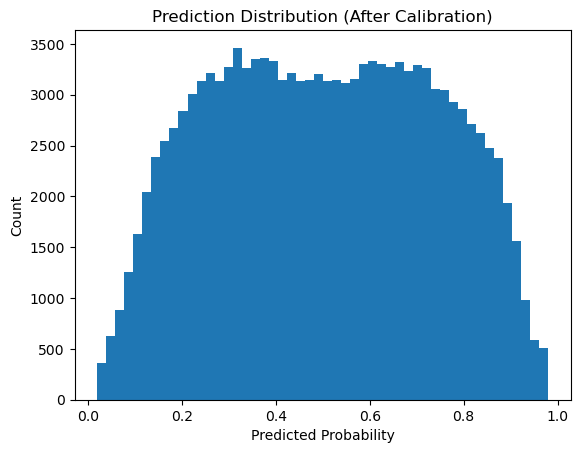

In [3]:
import matplotlib.pyplot as plt

plt.hist(submission["Pred"], bins=50)
plt.title("Prediction Distribution (After Calibration)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()